In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
df=pd.read_csv("Bares_T35_cleaned_data.csv")
# 1️⃣ Veri Hazırlama
# Zamanı datetime formatına çevir ve indeks yap
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 2️⃣ Feature Engineering (Özellik Mühendisliği)
# Lag (Gecikmeli) değişkenler oluştur (önceki zaman adımları)
for lag in [1, 2, 3, 6, 12]:
    df[f"BRS.T35_T_GBX_Avg_lag{lag}"] = df["BRS.T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean) ekleyerek trendi yakalamaya çalış
df["BRS.T35_T_GBX_Avg_roll"] = df["BRS.T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler ekle
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizle (Lag değişkenlerden dolayı oluşan eksik değerler)
df = df.dropna()

# 3️⃣ Modelleme için Bağımsız ve Bağımlı Değişkenleri Ayırma
X = df.drop(columns=["BRS.T35_T_GBX_Avg"])  # Özellikler (Bağımsız değişkenler)
y = df["BRS.T35_T_GBX_Avg"]  # Tahmin edilecek değer (Gearbox sıcaklığı)

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4️⃣ LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000, early_stopping_rounds=50, verbose_eval=100)

# 5️⃣ Tahmin Yapma
y_pred = model.predict(X_test)

# Hata metriği (RMSE) hesapla
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse}")

# 6️⃣ Sonuçları Görselleştirme
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Gerçek Sıcaklık", color="blue")
plt.plot(y_test.index, y_pred, label="Tahmin Edilen Sıcaklık", color="red", linestyle="dashed")
plt.axhline(y=65, color='black', linestyle='--', label="Threshold (65°C)")
plt.legend()
plt.title("Gerçek vs Tahmin Edilen Gearbox Sıcaklığı")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık (°C)")
plt.show()

# 7️⃣ Erken Uyarı Sistemi: Eğer model 65°C'yi geçeceğini tahmin ederse, uyarı ver
df_test = X_test.copy()
df_test["Gerçek"] = y_test
df_test["Tahmin"] = y_pred
df_test["Alarm"] = df_test["Tahmin"].apply(lambda x: "Yavaşlat" if x >= 65 else "Normal")

# Erken uyarıları kaydet
df_test.to_csv("Gearbox_Temperature_Threshold_Alarms.csv")

# Erken uyarı veren satırları göster
print(df_test[df_test["Alarm"] == "Yavaşlat"].head(10))


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

Model RMSE: 0.24840931984678313


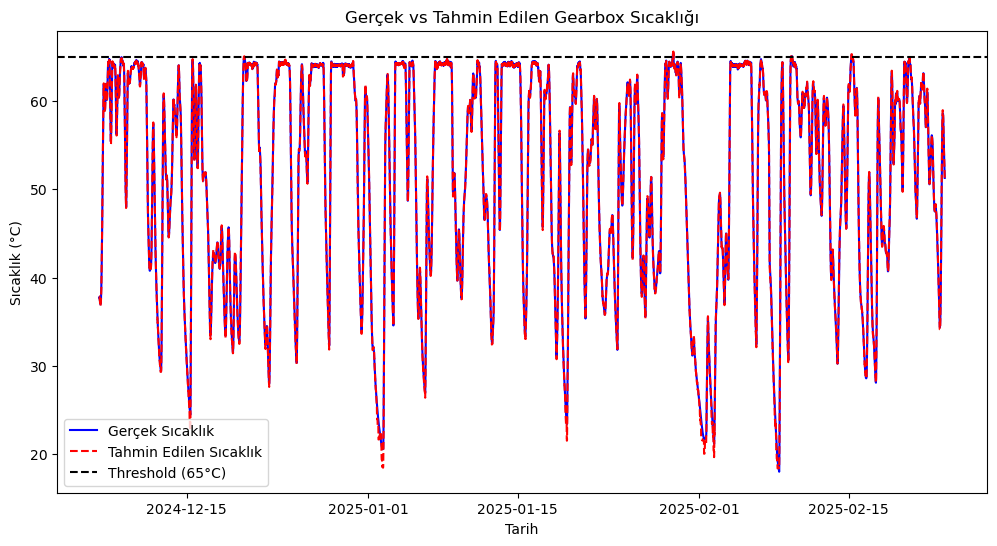

                     Unnamed__0  BRS_T35_N_ROT_PLC  BRS_T35_Power  \
Timestamp                                                           
2024-12-07 04:40:00       45676              12.33    1157.638004   
2024-12-07 04:50:00       45677              11.48    1164.018005   
2024-12-07 05:00:00       45678              10.62    1152.966507   
2024-12-07 05:10:00       45679               9.76    1146.257007   
2024-12-07 05:20:00       45680               8.91    1136.704508   
2024-12-07 05:30:00       45681               7.25    1115.450007   
2024-12-07 05:40:00       45682               8.69    1094.202508   
2024-12-07 05:50:00       45683               8.75    1063.100007   
2024-12-07 06:00:00       45684               8.82    1006.049006   
2024-12-07 06:10:00       45685               8.88     951.144008   

                     BRS_T35_T_GEAR_BEAR  BRS_T35_Temp_Ambient  \
Timestamp                                                        
2024-12-07 04:40:00              64.548

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Veri Yükleme
df = pd.read_csv("Bares_T35_cleaned_data.csv")

# 1. Sütun isimlerini temizleme (Özel karakterleri kaldır)
df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

# 2. Zaman Formatı ve İndeksleme
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 3. Özellik Mühendisliği
# Lag (Gecikmeli) değişkenler oluşturma
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df[f"BRS_T35_T_GBX_Avg_lag{lag}"] = df["BRS_T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean) ekleme
df["BRS_T35_T_GBX_Avg_roll"] = df["BRS_T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler ekleme
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizleme (Lag değişkenlerden dolayı oluşan eksik değerler)
df.dropna(inplace=True)

# 4. Modelleme için Bağımsız ve Bağımlı Değişkenleri Ayırma
X = df.drop(columns=["BRS_T35_T_GBX_Avg"])  # Özellikler (Bağımsız değişkenler)
y = df["BRS_T35_T_GBX_Avg"]  # Tahmin edilecek değer (Gearbox sıcaklığı)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000)

# 6. Tahmin Yapma
y_pred = model.predict(X_test)

# Hata metriği (RMSE) hesaplama
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse}")

# 7. Sonuçları Görselleştirme
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Gerçek Sıcaklık", color="blue")
plt.plot(y_test.index, y_pred, label="Tahmin Edilen Sıcaklık", color="red", linestyle="dashed")
plt.axhline(y=65, color='black', linestyle='--', label="Threshold (65°C)")
plt.legend()
plt.title("Gerçek vs Tahmin Edilen Gearbox Sıcaklığı")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık (°C)")
plt.show()

# 8. Erken Uyarı Sistemi
# Eğer model 65°C'yi geçeceğini tahmin ederse, uyarı ver
df_test = X_test.copy()
df_test["Gerçek"] = y_test
df_test["Tahmin"] = y_pred
df_test["Alarm"] = df_test["Tahmin"].apply(lambda x: "Yavaşlat" if x >= 60 else "Normal")

# Erken uyarıları kaydetme
df_test.to_csv("Gearbox_Temperature_Threshold_Alarms.csv")

# Erken uyarı veren satırları gösterme
print(df_test[df_test["Alarm"] == "Yavaşlat"].head(10))


Model RMSE: 0.24840931984678313


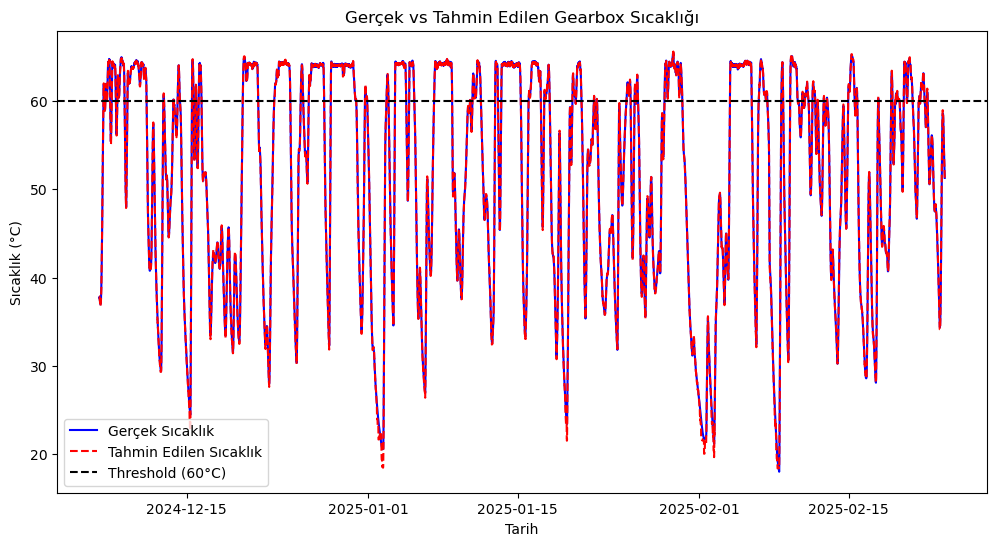

                     Unnamed__0  BRS_T35_N_ROT_PLC  BRS_T35_Power  \
Timestamp                                                           
2024-12-07 04:40:00       45676              12.33    1157.638004   
2024-12-07 04:50:00       45677              11.48    1164.018005   
2024-12-07 05:00:00       45678              10.62    1152.966507   
2024-12-07 05:10:00       45679               9.76    1146.257007   
2024-12-07 05:20:00       45680               8.91    1136.704508   
2024-12-07 05:30:00       45681               7.25    1115.450007   
2024-12-07 05:40:00       45682               8.69    1094.202508   
2024-12-07 05:50:00       45683               8.75    1063.100007   
2024-12-07 06:00:00       45684               8.82    1006.049006   
2024-12-07 06:10:00       45685               8.88     951.144008   

                     BRS_T35_T_GEAR_BEAR  BRS_T35_Temp_Ambient  \
Timestamp                                                        
2024-12-07 04:40:00              64.548

In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Veri Yükleme
df = pd.read_csv("Bares_T35_cleaned_data.csv")

# 1. Sütun isimlerini temizleme (Özel karakterleri kaldır)
df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

# 2. Zaman Formatı ve İndeksleme
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 3. Özellik Mühendisliği
# Lag (Gecikmeli) değişkenler oluşturma
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df[f"BRS_T35_T_GBX_Avg_lag{lag}"] = df["BRS_T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean) ekleme
df["BRS_T35_T_GBX_Avg_roll"] = df["BRS_T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler ekleme
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizleme (Lag değişkenlerden dolayı oluşan eksik değerler)
df.dropna(inplace=True)

# 4. Modelleme için Bağımsız ve Bağımlı Değişkenleri Ayırma
X = df.drop(columns=["BRS_T35_T_GBX_Avg"])  # Özellikler (Bağımsız değişkenler)
y = df["BRS_T35_T_GBX_Avg"]  # Tahmin edilecek değer (Gearbox sıcaklığı)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000)

# 6. Tahmin Yapma
y_pred = model.predict(X_test)

# Hata metriği (RMSE) hesaplama
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse}")

# 7. Sonuçları Görselleştirme
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Gerçek Sıcaklık", color="blue")
plt.plot(y_test.index, y_pred, label="Tahmin Edilen Sıcaklık", color="red", linestyle="dashed")
plt.axhline(y=60, color='black', linestyle='--', label="Threshold (60°C)")
plt.legend()
plt.title("Gerçek vs Tahmin Edilen Gearbox Sıcaklığı")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık (°C)")
plt.show()

# 8. Erken Uyarı Sistemi
# Eğer model 60°C'yi geçeceğini tahmin ederse, uyarı ver
df_test = X_test.copy()
df_test["Gerçek"] = y_test
df_test["Tahmin"] = y_pred
df_test["Alarm"] = df_test["Tahmin"].apply(lambda x: "Yavaşlat" if x >= 60 else "Normal")

# Erken uyarıları kaydetme
df_test.to_csv("Gearbox_Temperature_Threshold_Alarms.csv")

# Erken uyarı veren satırları gösterme
print(df_test[df_test["Alarm"] == "Yavaşlat"].head(10))


Model RMSE: 0.24840931984678313


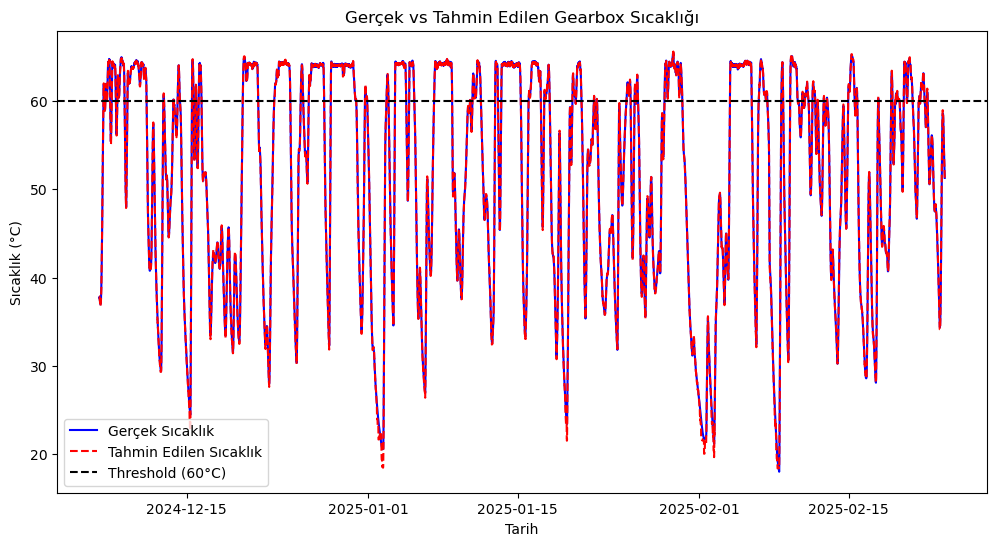

                     Unnamed__0  BRS_T35_N_ROT_PLC  BRS_T35_Power  \
Timestamp                                                           
2024-12-07 04:40:00       45676              12.33    1157.638004   
2024-12-07 04:50:00       45677              11.48    1164.018005   
2024-12-07 05:00:00       45678              10.62    1152.966507   
2024-12-07 05:10:00       45679               9.76    1146.257007   
2024-12-07 05:20:00       45680               8.91    1136.704508   
2024-12-07 05:30:00       45681               7.25    1115.450007   
2024-12-07 05:40:00       45682               8.69    1094.202508   
2024-12-07 05:50:00       45683               8.75    1063.100007   
2024-12-07 06:00:00       45684               8.82    1006.049006   
2024-12-07 06:10:00       45685               8.88     951.144008   

                     BRS_T35_T_GEAR_BEAR  BRS_T35_Temp_Ambient  \
Timestamp                                                        
2024-12-07 04:40:00              64.548

In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 📌 1. Veri Yükleme
df = pd.read_csv("Bares_T35_cleaned_data.csv")

# 📌 2. Sütun isimlerini temizleme (Özel karakterleri kaldır)
df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

# 📌 3. Zaman Formatı ve İndeksleme
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 📌 4. Özellik Mühendisliği
# Gecikmeli değişkenler ekleme
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df[f"BRS_T35_T_GBX_Avg_lag{lag}"] = df["BRS_T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean)
df["BRS_T35_T_GBX_Avg_roll"] = df["BRS_T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizle
df.dropna(inplace=True)

# 📌 5. Bağımsız ve Bağımlı Değişkenleri Ayırma
X = df.drop(columns=["BRS_T35_T_GBX_Avg"])  # Özellikler
y = df["BRS_T35_T_GBX_Avg"]  # Tahmin edilecek değer

# 📌 6. Eğitim ve Test Setlerine Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 📌 7. LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000)

# 📌 8. Tahmin Yapma
y_pred = model.predict(X_test)

# 📌 9. Sonuçları Değerlendirme
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse}")

# 📌 10. Tahmin Sonuçlarını ve Gerçek Değerleri Karşılaştırma
df_results = X_test.copy()
df_results["Gerçek"] = y_test
df_results["Tahmin"] = y_pred

# 📌 11. Erken Uyarı Sistemi
df_results["Alarm"] = df_results["Tahmin"].apply(lambda x: "Yavaşlat" if x >= 60 else "Normal")

# 📌 12. Sonuçları Kaydetme
df_results.to_csv("Gearbox_Temperature_Threshold_Alarms.csv", index=True)

# 📌 13. Grafikte Görselleştirme
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Gerçek Sıcaklık", color="blue")
plt.plot(y_test.index, y_pred, label="Tahmin Edilen Sıcaklık", color="red", linestyle="dashed")
plt.axhline(y=60, color='black', linestyle='--', label="Threshold (60°C)")
plt.legend()
plt.title("Gerçek vs Tahmin Edilen Gearbox Sıcaklığı")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık (°C)")
plt.show()

# 📌 14. Erken Uyarı Veren Satırları Gösterme
print(df_results[df_results["Alarm"] == "Yavaşlat"].head(10))


In [24]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 1. Veri Yükleme
df = pd.read_csv("Bares_T35_cleaned_data.csv")

# 📌 2. Sütun isimlerini temizleme (Özel karakterleri kaldır)
df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

# 📌 3. Zaman Formatı ve İndeksleme
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 📌 4. Özellik Mühendisliği
# Gecikmeli değişkenler (Lag Features) ekleme
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df[f"BRS_T35_T_GBX_Avg_lag{lag}"] = df["BRS_T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean) ekleme
df["BRS_T35_T_GBX_Avg_roll"] = df["BRS_T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler ekleme
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizleme (Lag değişkenlerden dolayı oluşan eksik değerler)
df.dropna(inplace=True)

# 📌 5. Veri Setini %70 Eğitim - %30 Test Olarak Ayırma
split_index = int(len(df) * 0.7)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

# Bağımsız ve bağımlı değişkenleri ayırma
X_train, y_train = df_train.drop(columns=["BRS_T35_T_GBX_Avg"]), df_train["BRS_T35_T_GBX_Avg"]
X_test, y_test = df_test.drop(columns=["BRS_T35_T_GBX_Avg"]), df_test["BRS_T35_T_GBX_Avg"]

# 📌 6. LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000)

# 📌 7. Tahmin Yapma
y_pred = model.predict(X_test)

# 📌 8. Performans Metriklerini Hesaplama
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 📌 9. Sonuçları Yazdırma
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")


Mean Squared Error (MSE): 0.5864
Root Mean Squared Error (RMSE): 0.7658
Mean Absolute Error (MAE): 0.2358
R^2 Score: 0.9965


In [32]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, recall_score, precision_score

# 📌 1. Veri Yükleme
df = pd.read_csv("Bares_T35_cleaned_data.csv")

# 📌 2. Sütun isimlerini temizleme (Özel karakterleri kaldır)
df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

# 📌 3. Zaman Formatı ve İndeksleme
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# 📌 4. Özellik Mühendisliği
# Gecikmeli değişkenler (Lag Features) ekleme
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df[f"BRS_T35_T_GBX_Avg_lag{lag}"] = df["BRS_T35_T_GBX_Avg"].shift(lag)

# Hareketli Ortalama (Rolling Mean) ekleme
df["BRS_T35_T_GBX_Avg_roll"] = df["BRS_T35_T_GBX_Avg"].rolling(window=6, min_periods=1).mean()

# Zaman bazlı özellikler ekleme
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month

# NaN değerleri temizleme (Lag değişkenlerden dolayı oluşan eksik değerler)
df.dropna(inplace=True)

# 📌 5. Veri Setini %70 Eğitim - %30 Test Olarak Ayırma
split_index = int(len(df) * 0.7)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

# Bağımsız ve bağımlı değişkenleri ayırma
X_train, y_train = df_train.drop(columns=["BRS_T35_T_GBX_Avg"]), df_train["BRS_T35_T_GBX_Avg"]
X_test, y_test = df_test.drop(columns=["BRS_T35_T_GBX_Avg"]), df_test["BRS_T35_T_GBX_Avg"]

# 📌 6. LightGBM Modelini Eğitme
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "verbose": -1
}

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=1000)

# 📌 7. Tahmin Yapma
y_pred = model.predict(X_test)

# 📌 8. Regresyon Metriklerini Hesaplama
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 📌 9. Sınıflandırma Metriklerini Hesaplama (60°C'yi geçen tahminleri tespit et)
threshold = 60  # Sıcaklık eşiği
y_test_class = (y_test >= threshold).astype(int)  # Gerçek değerler (1: 60°C üstü, 0: 60°C altı)
y_pred_class = (y_pred >= threshold).astype(int)  # Tahmin edilen değerler

f1 = f1_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)

# 📌 10. Sonuçları Yazdırma
print(f"📌 Regresyon Metrikleri:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

print("\n📌 Sınıflandırma Metrikleri (60°C Eşiğine Göre):")
print(f"F1 Score: {f1:.4f}")
print(f"Recall (Duyarlılık): {recall:.4f}")
print(f"Precision (Kesinlik): {precision:.4f}")


📌 Regresyon Metrikleri:
Mean Squared Error (MSE): 0.5864
Root Mean Squared Error (RMSE): 0.7658
Mean Absolute Error (MAE): 0.2358
R^2 Score: 0.9965

📌 Sınıflandırma Metrikleri (60°C Eşiğine Göre):
F1 Score: 0.9940
Recall (Duyarlılık): 0.9955
Precision (Kesinlik): 0.9926
